# Olist Delivery Reliability and Operational Risk Analysis

**Business question:** The review-text analysis found that delivery and
fulfilment failures are concentrated among severe customer complaints. Where do
the corresponding operational failures develop, which sellers and state routes
create the greatest avoidable volume, and what targeted controls should Olist
test?

The analysis does not describe Olist as having a platform-wide delivery crisis.
Most orders arrive on time. Its purpose is to locate the smaller failure tail
that creates disproportionate dissatisfaction and turn it into measurable
operational interventions.

## Analytical flow

1. Load the same Snowflake/dbt semantic layer used by Power BI.
2. Load the decision-ready handoff exported by the review-text notebook.
3. Reconcile overall order and delivery baselines.
4. Measure the relationship between objective lateness and low review scores.
5. Separate missed seller handovers from post-handover delivery failures.
6. Rank sellers and state routes by excess late-order volume.
7. Check whether cross-state commerce provides observable assortment or price
   value before proposing restrictions.
8. Size transparent what-if scenarios and define controlled pilots.

Historical associations and scenarios support prioritisation. Only a controlled
pilot can measure the causal impact of an intervention.

## 1. Connect to the Snowflake semantic layer

This notebook reads the curated dbt facts and dimensions rather than the raw
Kaggle files. Credentials remain in the local `.env` file and must never be
committed to the repository.

In [1]:
# Importing analysis libraries
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import snowflake.connector
from cryptography.hazmat.primitives import serialization
from dotenv import load_dotenv
from scipy.stats import chi2_contingency

try:
    from IPython.display import display
except ImportError:
    def display(value):
        print(value)

In [2]:
# Applying a consistent Olist-inspired visual theme
BLUE = "#0A4EE4"
ORANGE = "#E64E36"
NAVY = "#011647"
LIGHT_BLUE = "#B9CCFA"
VANILLA = "#F2F0E8"
GREY = "#6B7280"

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["axes.titlecolor"] = NAVY
plt.rcParams["axes.labelcolor"] = NAVY

In [3]:
# Loading the existing project environment settings
load_dotenv(override=True)

DBT_MODELS = {
    "orders": "FCT_OLIST__ORDERS",
    "items": "FCT_OLIST__ORDER_ITEMS",
    "reviews": "FCT_OLIST__ORDER_REVIEWS",
    "customers": "DIM_OLIST__CUSTOMERS",
    "products": "DIM_OLIST__PRODUCTS",
    "sellers": "DIM_OLIST__SELLERS"
}

In [4]:
# Checking that the Snowflake settings are available
required_variables = [
    "SNOWFLAKE_PRIVATE_KEY_FILE",
    "SNOWFLAKE_ACCOUNT",
    "SNOWFLAKE_USER",
    "SNOWFLAKE_WAREHOUSE",
    "SNOWFLAKE_DATABASE",
    "SNOWFLAKE_SCHEMA"
]

missing_variables = [
    name for name in required_variables
    if not os.getenv(name)
]

if missing_variables:
    raise EnvironmentError(
        f"Missing Snowflake settings: {missing_variables}"
    )

In [5]:
# Connecting with the project's existing key-pair authentication
key_path = os.getenv("SNOWFLAKE_PRIVATE_KEY_FILE")
passphrase = os.getenv("SNOWFLAKE_PRIVATE_KEY_PASSPHRASE")
key_password = passphrase.encode() if passphrase else None

with open(key_path, "rb") as key_file:
    private_key = serialization.load_pem_private_key(
        key_file.read(),
        password=key_password
    )

In [6]:
# Opening the Snowflake session
conn = snowflake.connector.connect(
    account=os.getenv("SNOWFLAKE_ACCOUNT"),
    user=os.getenv("SNOWFLAKE_USER"),
    authenticator="SNOWFLAKE_JWT",
    private_key=private_key,
    warehouse=os.getenv("SNOWFLAKE_WAREHOUSE"),
    database=os.getenv("SNOWFLAKE_DATABASE"),
    schema=os.getenv("SNOWFLAKE_SCHEMA")
)

print("Connected to Snowflake.")

Connected to Snowflake.


In [7]:
# Reading one dbt model and standardising column names
def read_dbt_model(model_name):
    query = f'''SELECT * FROM {model_name}'''
    cursor = conn.cursor()

    try:
        cursor.execute(query)
        dataframe = cursor.fetch_pandas_all()
    finally:
        cursor.close()

    dataframe.columns = dataframe.columns.str.lower()
    return dataframe

## 2. Load the operational models and review-analysis handoff

The structured analysis uses orders, items, reviews, customers, products and
sellers. The separate review-text notebook remains the source of qualitative
themes and exports the non-receipt cases used here.

In [8]:
# Loading the core fact tables
orders_df = read_dbt_model(DBT_MODELS["orders"])
items_df = read_dbt_model(DBT_MODELS["items"])
reviews_df = read_dbt_model(DBT_MODELS["reviews"])

In [9]:
# Loading the supporting dimensions
customers_df = read_dbt_model(DBT_MODELS["customers"])
products_df = read_dbt_model(DBT_MODELS["products"])
sellers_df = read_dbt_model(DBT_MODELS["sellers"])

In [10]:
# Closing the remote session after loading the required data
conn.close()

source_shapes = pd.Series({
    "orders": len(orders_df),
    "order_items": len(items_df),
    "reviews": len(reviews_df),
    "customers": len(customers_df),
    "sellers": len(sellers_df),
    "products": len(products_df)
})
display(source_shapes.to_frame("rows"))

,rows
orders,99441
order_items,112650
reviews,99224
customers,96096
sellers,3095
products,32951


In [11]:
# Aligning dbt field names with the analytical names used below
if "order_purchase_timestamp" not in orders_df.columns:
    orders_df = orders_df.rename(
        columns={"order_purchase_date": "order_purchase_timestamp"}
    )

if "satisfaction_score" in reviews_df.columns:
    reviews_df = reviews_df.rename(
        columns={"satisfaction_score": "review_score"}
    )

In [12]:
# Aligning the review timestamps retained by the dbt model
review_column_names = {
    "survey_issued_at": "review_creation_date",
    "survey_submitted_at": "review_answer_timestamp"
}

reviews_df = reviews_df.rename(
    columns=review_column_names
)

In [13]:
# Converting Snowflake date and timestamp fields for pandas
order_date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in order_date_columns:
    orders_df[column] = pd.to_datetime(
        orders_df[column],
        errors="coerce"
    )

In [15]:
# Converting item and review timestamps
items_df["carrier_handover_deadline"] = pd.to_datetime(
    items_df["carrier_handover_deadline"],
    errors="coerce"
)

for column in ["review_creation_date", "review_answer_timestamp"]:
    reviews_df[column] = pd.to_datetime(
        reviews_df[column],
        errors="coerce"
    )

In [16]:
# Locating the outputs from the review-text notebook
review_output_dir = Path(
    os.getenv(
        "OLIST_REVIEW_OUTPUT_DIR",
        "outputs/review_text_customer_experience"
    )
)
negative_theme_path = (
    review_output_dir / "negative_subtopic_summary.csv"
)
non_receipt_audit_path = (
    review_output_dir / "non_receipt_order_audit.parquet"
)

In [17]:
# Requiring the completed review-text handoff
missing_review_outputs = [
    str(path)
    for path in [negative_theme_path, non_receipt_audit_path]
    if not path.exists()
]

if missing_review_outputs:
    raise FileNotFoundError(
        "Run the customer-experience review notebook first. "
        f"Missing outputs: {missing_review_outputs}"
    )

In [18]:
# Loading and validating the review-text handoff
negative_subtopic_summary = pd.read_csv(negative_theme_path)
non_receipt_audit_df = pd.read_parquet(non_receipt_audit_path)

required_audit_columns = {"order_id", "recorded_outcome"}
missing_audit_columns = (
    required_audit_columns - set(non_receipt_audit_df.columns)
)
if missing_audit_columns:
    raise ValueError(
        f"Missing review-audit columns: {sorted(missing_audit_columns)}"
    )

assert non_receipt_audit_df["order_id"].is_unique

## 3. Create one operational record per order

In [19]:
# Keeping the latest available review score for each order
if "review_sequence" in reviews_df.columns:
    reviews_df = reviews_df[
        reviews_df["review_sequence"] == 1
    ].copy()

latest_review_df = (
    reviews_df
    .sort_values([
        "order_id",
        "review_answer_timestamp",
        "review_creation_date"
    ])
    .drop_duplicates("order_id", keep="last")
    [["order_id", "review_score"]]
)

assert latest_review_df["order_id"].is_unique

In [20]:
# Selecting the translated category supplied by the product dimension
if "product_category_name_english" in products_df.columns:
    product_category_column = "product_category_name_english"
elif "product_category_name" in products_df.columns:
    product_category_column = "product_category_name"
else:
    raise KeyError("No product-category field found in DIM_OLIST__PRODUCTS.")

product_lookup_df = products_df[
    ["product_id", product_category_column]
].rename(columns={
    product_category_column: "product_category_name_english"
})

In [21]:
# Adding readable product categories to the item fact
items_enriched_df = items_df.merge(
    product_lookup_df,
    on="product_id",
    how="left",
    validate="many_to_one"
)

In [23]:
# Creating order-level item and shipping information
order_item_summary_df = (
    items_enriched_df
    .groupby("order_id", as_index=False)
    .agg(
        item_count = ("order_item_id", "size"),
        seller_count = ("seller_id", "nunique"),
        seller_id = ("seller_id", "first"),
        carrier_handover_deadline = ("carrier_handover_deadline", "min"),
        product_value = ("price", "sum"),
        shipping_cost = ("shipping_cost", "sum")
    )
)

In [24]:
# Identifying the highest-value category in each order
category_value_df = (
    items_enriched_df
    .groupby([
        "order_id",
        "product_category_name_english"
    ], as_index=False)["price"]
    .sum()
)

primary_category_df = (
    category_value_df
    .sort_values(["order_id", "price"], ascending=[True, False])
    .drop_duplicates("order_id")
    .rename(columns={"product_category_name_english": "primary_category"})
    [["order_id", "primary_category"]]
)

In [25]:
# Adding customer geography when it is not already in the order fact
order_analysis_df = orders_df.copy()

if "customer_state" not in order_analysis_df.columns:
    order_analysis_df = order_analysis_df.merge(
        customers_df[["customer_id", "customer_state"]],
        on="customer_id",
        how="left",
        validate="many_to_one"
    )

order_analysis_df = order_analysis_df.merge(
    order_item_summary_df,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [26]:
# Adding seller, category and structured review information
if "seller_state" not in order_analysis_df.columns:
    order_analysis_df = order_analysis_df.merge(
        sellers_df[["seller_id", "seller_state"]],
        on="seller_id",
        how="left",
        validate="many_to_one"
    )

order_analysis_df = order_analysis_df.merge(
    primary_category_df,
    on="order_id",
    how="left",
    validate="one_to_one"
)

order_analysis_df = order_analysis_df.merge(
    latest_review_df,
    on="order_id",
    how="left",
    validate="one_to_one"
)

In [27]:
# Attaching the reconciled non-receipt outcome to each order
review_delivery_handoff_df = non_receipt_audit_df[[
    "order_id", "recorded_outcome"
]].copy()

order_analysis_df = order_analysis_df.merge(
    review_delivery_handoff_df,
    on="order_id",
    how="left",
    validate="one_to_one"
)
order_analysis_df["reported_non_receipt"] = (
    order_analysis_df["recorded_outcome"].notna()
)

In [28]:
# Creating operational flags from the review reconciliation
order_analysis_df["delivery_record_discrepancy"] = (
    order_analysis_df["recorded_outcome"]
    == "Review submitted after recorded delivery"
)
order_analysis_df["eventual_late_after_report"] = (
    order_analysis_df["recorded_outcome"]
    == "Eventually delivered late after review"
)
order_analysis_df["no_recorded_delivery_report"] = (
    order_analysis_df["recorded_outcome"]
    == "No recorded delivery"
)

In [29]:
# Validating the analytical grain and review handoff coverage
assert order_analysis_df["order_id"].is_unique
assert len(order_analysis_df) == len(orders_df)
assert set(non_receipt_audit_df["order_id"]).issubset(
    set(order_analysis_df["order_id"])
)

quality_checks = pd.Series({
    "unique_orders": order_analysis_df["order_id"].nunique(),
    "orders_with_items": order_analysis_df["item_count"].notna().sum(),
    "orders_with_review_score": order_analysis_df["review_score"].notna().sum(),
    "multi_seller_orders": (order_analysis_df["seller_count"] > 1).sum(),
    "reconciled_non_receipt_reports": (
        order_analysis_df["reported_non_receipt"].sum()
    )
})
display(quality_checks.to_frame("orders"))

,orders
unique_orders,99441
orders_with_items,98666
orders_with_review_score,98673
multi_seller_orders,1278
reconciled_non_receipt_reports,1036


## 4. Reconcile the overall fulfilment baseline

This short section confirms that the notebook uses the same curated population
as the dashboard. The delivered majority establishes why the solution should be
targeted rather than applied indiscriminately to every order.

In [30]:
# Summarising order status volume and share
status_summary_df = (
    order_analysis_df["order_status"]
    .value_counts()
    .rename_axis("order_status")
    .reset_index(name="orders")
)

status_summary_df["order_share_pct"] = (
    status_summary_df["orders"] / status_summary_df["orders"].sum() * 100
)

display(status_summary_df.round(2))

,order_status,orders,order_share_pct
0,delivered,96478,97.02
1,shipped,1107,1.11
2,canceled,625,0.63
3,unavailable,609,0.61
4,invoiced,314,0.32
5,processing,301,0.30
6,created,5,0.01
7,approved,2,0.00


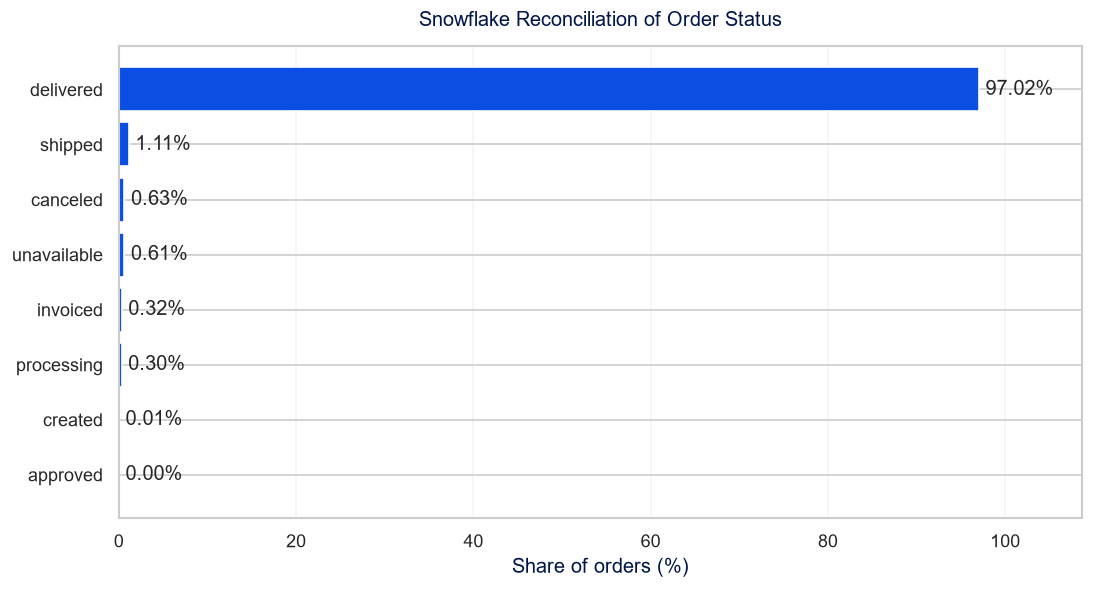

In [31]:
# Visualising the overall order-status distribution
status_plot_df = status_summary_df.sort_values("orders")

fig, ax = plt.subplots(figsize=(9, 4.8), layout="constrained")
bars = ax.barh(
    status_plot_df["order_status"],
    status_plot_df["order_share_pct"],
    color=BLUE
)
ax.bar_label(bars, fmt="%.2f%%", padding=4)
ax.set_title("Snowflake Reconciliation of Order Status", pad=12)
ax.set_xlabel("Share of orders (%)")
ax.set_ylabel("")
ax.set_xlim(0, status_plot_df["order_share_pct"].max() * 1.12)
ax.grid(axis="x", alpha=0.2)
plt.show()

Most orders reached a delivered status. The remaining analysis therefore asks
whether the smaller late and disputed-delivery groups create disproportionate
customer harm and whether those failures concentrate operationally.

## 5. Define objective delivery and customer-experience outcomes

Delivery is late only when the recorded delivery **calendar date** follows the
estimated calendar date. The estimated timestamp is stored at midnight, so a
full timestamp comparison would incorrectly label delivery later on the promised
day as late.

In [32]:
# Creating the delivered-order analysis cohort
delivery_df = order_analysis_df[
    (order_analysis_df["order_status"] == "delivered")
    & order_analysis_df["order_delivered_customer_date"].notna()
    & order_analysis_df["order_estimated_delivery_date"].notna()
].copy()

delivery_df["actual_delivery_days"] = (
    delivery_df["order_delivered_customer_date"].dt.normalize()
    - delivery_df["order_purchase_timestamp"].dt.normalize()
).dt.days

In [33]:
# Calculating delivery performance and a nullable low-review flag
delivery_df["delivery_delay_days"] = (
    delivery_df["order_delivered_customer_date"].dt.normalize()
    - delivery_df["order_estimated_delivery_date"].dt.normalize()
).dt.days
delivery_df["is_late_delivery"] = (
    delivery_df["delivery_delay_days"] > 0
)
delivery_df["low_review"] = pd.Series(
    np.where(
        delivery_df["review_score"].notna(),
        delivery_df["review_score"] <= 2,
        pd.NA
    ),
    index=delivery_df.index,
    dtype="boolean"
)
delivery_df["delivery_outcome"] = np.where(
    delivery_df["is_late_delivery"], "Late", "On time"
)

In [34]:
# Reporting the main delivery and satisfaction baseline
late_orders = int(delivery_df["is_late_delivery"].sum())
reviewed_deliveries = int(delivery_df["review_score"].notna().sum())

delivery_kpis = pd.Series({
    "delivered_orders": len(delivery_df),
    "late_orders": late_orders,
    "late_delivery_rate_pct": delivery_df["is_late_delivery"].mean() * 100,
    "median_delivery_days": delivery_df["actual_delivery_days"].median(),
    "reviewed_deliveries": reviewed_deliveries,
    "low_review_rate_pct": delivery_df.loc[
        delivery_df["review_score"].notna(), "low_review"
    ].mean() * 100
})
display(delivery_kpis.round(2).to_frame("value"))

,value
delivered_orders,96470.00
late_orders,6534.00
late_delivery_rate_pct,6.77
median_delivery_days,10.00
reviewed_deliveries,95824.00
low_review_rate_pct,12.81


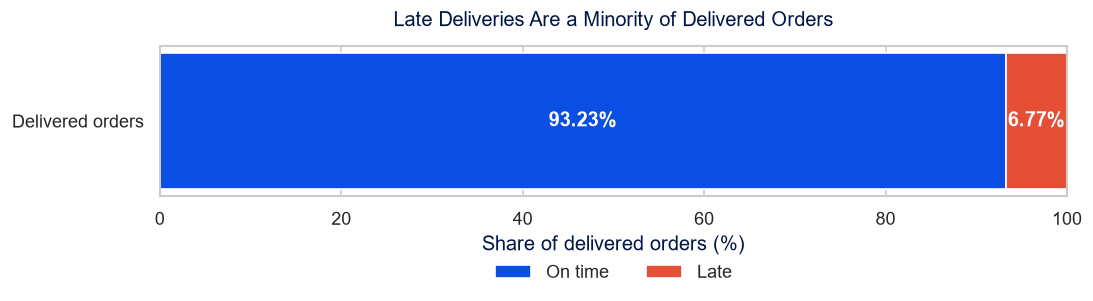

In [35]:
# Showing how delivered orders divide between on-time and late
outcome_share_df = (
    delivery_df["delivery_outcome"]
    .value_counts(normalize=True)
    .reindex(["On time", "Late"])
    .fillna(0)
    * 100
)

fig, ax = plt.subplots(figsize=(9, 2.3), layout="constrained")
left = 0
for label, color in [("On time", BLUE), ("Late", ORANGE)]:
    value = outcome_share_df[label]
    ax.barh(["Delivered orders"], [value], left=left, color=color, label=label)
    ax.text(left + value / 2, 0, f"{value:.2f}%", ha="center", va="center", color="white", weight="bold")
    left += value
ax.set_title("Late Deliveries Are a Minority of Delivered Orders", pad=12)
ax.set_xlim(0, 100)
ax.set_xlabel("Share of delivered orders (%)")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.35), ncol=2, frameon=False)
plt.show()

## 6. Confirm the review-text handoff

The review notebook establishes the customer voice. This section does not repeat
topic modelling; it verifies the exact exported counts before the structured
operational diagnosis begins.

In [36]:
# Retrieving named review-theme counts without hard-coding them
theme_count_lookup = negative_subtopic_summary.set_index(
    "subtopic_label_en"
)["unique_orders"]

def get_theme_count(label):
    return int(theme_count_lookup.get(label, 0))


named_low_score_orders = int(
    negative_subtopic_summary["unique_orders"].sum()
)

In [37]:
# Summarising the customer-experience evidence handed into this notebook
outcome_counts = non_receipt_audit_df[
    "recorded_outcome"
].value_counts()

review_handoff_kpis = pd.Series({
    "named_low_score_theme_orders": named_low_score_orders,
    "low_score_non_receipt_reports": get_theme_count(
        "Non-receipt reported at review time"
    ),
    "low_score_late_or_slow_reports": get_theme_count(
        "Late or slow delivery"
    ),
    "all_reconciled_non_receipt_reports": len(non_receipt_audit_df),
    "eventually_delivered_late": int(outcome_counts.get(
        "Eventually delivered late after review", 0
    )),
    "delivery_record_discrepancies": int(outcome_counts.get(
        "Review submitted after recorded delivery", 0
    )),
    "no_recorded_delivery": int(outcome_counts.get(
        "No recorded delivery", 0
    ))
})
display(review_handoff_kpis.to_frame("orders"))

,orders
named_low_score_theme_orders,4651
low_score_non_receipt_reports,848
low_score_late_or_slow_reports,506
all_reconciled_non_receipt_reports,1036
eventually_delivered_late,427
delivery_record_discrepancies,391
no_recorded_delivery,128


The review evidence justifies investigation because delivery and fulfilment
problems are prominent within severe feedback, not because most Olist orders
failed. The operational sections below test where objective lateness and
delivery-record discrepancies concentrate.

## 7. Test whether objective lateness is associated with low ratings

The comparison uses delivered orders with a recorded review score. Practical
differences and effect size are reported alongside statistical significance so
the large sample does not make a negligible difference look important.

In [38]:
# Comparing satisfaction outcomes for on-time and late deliveries
delivery_review_summary_df = (
    delivery_df[delivery_df["review_score"].notna()]
    .groupby("delivery_outcome", as_index=False)
    .agg(
        reviewed_orders=("order_id", "nunique"),
        average_review_score=("review_score", "mean"),
        low_reviews=("low_review", "sum"),
        low_review_rate=("low_review", "mean")
    )
)

delivery_review_summary_df["low_review_rate_pct"] = (
    delivery_review_summary_df["low_review_rate"] * 100
)
display(delivery_review_summary_df.round(2))

,delivery_outcome,reviewed_orders,average_review_score,low_reviews,low_review_rate,low_review_rate_pct
0,Late,6381,2.27,3983,0.62,62.42
1,On time,89443,4.29,8289,0.09,9.27


In [39]:
# Measuring the association between lateness and low reviews
reviewed_delivery_df = delivery_df[delivery_df["review_score"].notna()].copy()
contingency_table = pd.crosstab(
    reviewed_delivery_df["is_late_delivery"],
    reviewed_delivery_df["low_review"]
)

chi_square, p_value, _, _ = chi2_contingency(contingency_table)
cramers_v = np.sqrt(chi_square / contingency_table.to_numpy().sum())

late_low_rate = reviewed_delivery_df.loc[
    reviewed_delivery_df["is_late_delivery"], "low_review"
].mean()
on_time_low_rate = reviewed_delivery_df.loc[
    ~reviewed_delivery_df["is_late_delivery"], "low_review"
].mean()

In [40]:
# Reporting practical and statistical effect measures
risk_difference_pp = (late_low_rate - on_time_low_rate) * 100
risk_ratio = late_low_rate / on_time_low_rate

association_results = pd.Series({
    "on_time_low_review_rate_pct": on_time_low_rate * 100,
    "late_low_review_rate_pct": late_low_rate * 100,
    "risk_difference_pp": risk_difference_pp,
    "risk_ratio": risk_ratio,
    "chi_square": chi_square,
    "p_value": p_value,
    "cramers_v": cramers_v
})
display(association_results.round(4).to_frame("value"))

,value
on_time_low_review_rate_pct,9.2674
late_low_review_rate_pct,62.4197
risk_difference_pp,53.1523
risk_ratio,6.7354
chi_square,15064.1490
p_value,0.0000
cramers_v,0.3965


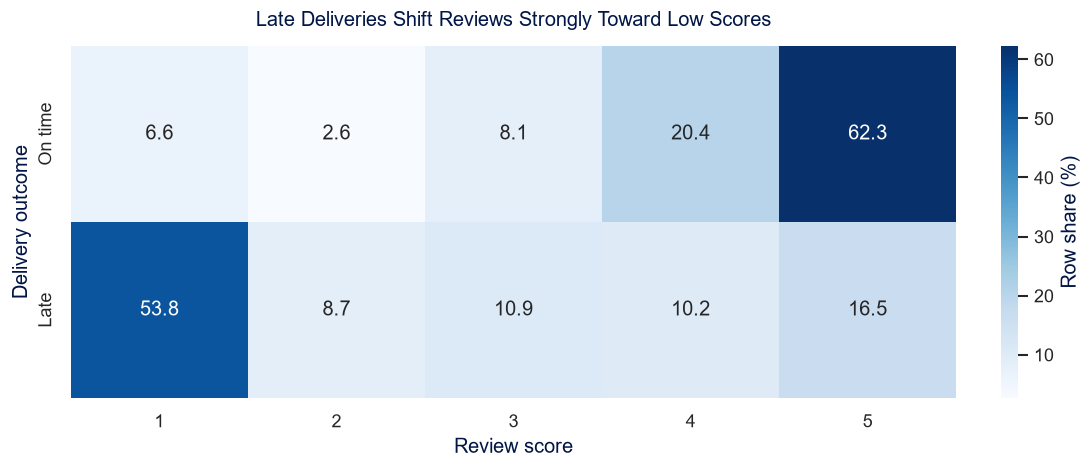

In [41]:
# Comparing the complete review-score mix by delivery outcome
score_mix_df = pd.crosstab(
    reviewed_delivery_df["delivery_outcome"],
    reviewed_delivery_df["review_score"].astype(int),
    normalize="index"
) * 100

score_mix_df = score_mix_df.reindex(["On time", "Late"])

fig, ax = plt.subplots(figsize=(9, 3.8), layout="constrained")
sns.heatmap(score_mix_df, annot=True, fmt=".1f", cmap="Blues", cbar_kws={"label": "Row share (%)"}, ax=ax)
ax.set_title("Late Deliveries Shift Reviews Strongly Toward Low Scores", pad=12)
ax.set_xlabel("Review score")
ax.set_ylabel("Delivery outcome")
plt.show()

In [42]:
# Quantifying the concentration of low and one-star reviews
late_reviewed_df = reviewed_delivery_df[reviewed_delivery_df["is_late_delivery"]]

review_concentration = pd.Series({
    "late_share_of_delivered_orders_pct": delivery_df["is_late_delivery"].mean() * 100,
    "late_share_of_low_reviews_pct": (
        late_reviewed_df["low_review"].sum() / reviewed_delivery_df["low_review"].sum() * 100
    ),
    "late_share_of_one_star_reviews_pct": (
        (late_reviewed_df["review_score"] == 1).sum()
        / (reviewed_delivery_df["review_score"] == 1).sum() * 100
    )
})
display(review_concentration.round(2).to_frame("value"))

,value
late_share_of_delivered_orders_pct,6.77
late_share_of_low_reviews_pct,32.46
late_share_of_one_star_reviews_pct,36.69


The comparison determines whether the smaller late-delivery group experiences a
meaningfully higher low-score rate. It demonstrates customer-experience exposure,
not that lateness caused every low rating.

## 8. Examine the severity of late deliveries

Days late separates small promise misses from severe failures that may require
proactive communication or service recovery.

In [43]:
# Summarising delay severity among late deliveries
late_delivery_df = delivery_df[delivery_df["is_late_delivery"]].copy()

delay_severity = pd.Series({
    "late_orders": len(late_delivery_df),
    "median_days_late": late_delivery_df["delivery_delay_days"].median(),
    "p75_days_late": late_delivery_df["delivery_delay_days"].quantile(0.75),
    "p90_days_late": late_delivery_df["delivery_delay_days"].quantile(0.90),
    "more_than_7_days_late_pct": (
        (late_delivery_df["delivery_delay_days"] > 7).mean() * 100
    ),
    "more_than_14_days_late_pct": (
        (late_delivery_df["delivery_delay_days"] > 14).mean() * 100
    )
})
display(delay_severity.round(2).to_frame("value"))

,value
late_orders,6534.00
median_days_late,7.00
p75_days_late,13.00
p90_days_late,22.00
more_than_7_days_late_pct,43.80
more_than_14_days_late_pct,21.18


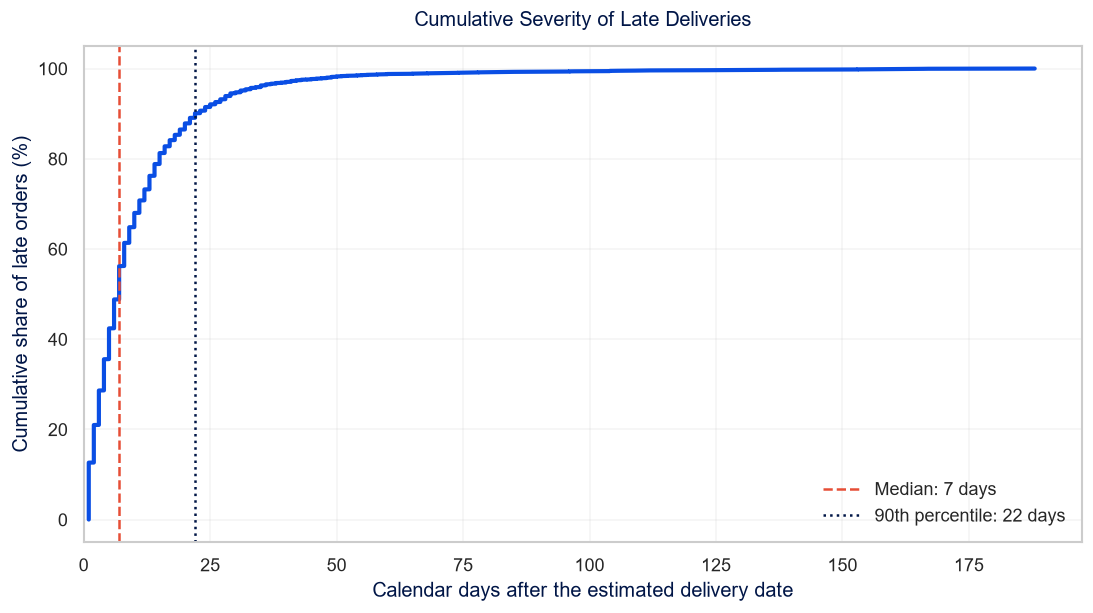

In [44]:
# Visualising the cumulative distribution of days late
sorted_delay = np.sort(late_delivery_df["delivery_delay_days"].dropna())
cumulative_share = np.arange(1, len(sorted_delay) + 1) / len(sorted_delay) * 100

fig, ax = plt.subplots(figsize=(9, 5), layout="constrained")
ax.plot(sorted_delay, cumulative_share, color=BLUE, linewidth=2.5)
ax.axvline(np.median(sorted_delay), color=ORANGE, linestyle="--", label=f"Median: {np.median(sorted_delay):.0f} days")
ax.axvline(np.quantile(sorted_delay, 0.90), color=NAVY, linestyle=":", label=f"90th percentile: {np.quantile(sorted_delay, 0.90):.0f} days")
ax.set_title("Cumulative Severity of Late Deliveries", pad=12)
ax.set_xlabel("Calendar days after the estimated delivery date")
ax.set_ylabel("Cumulative share of late orders (%)")
ax.set_xlim(left=0)
ax.legend(frameon=False)
ax.grid(alpha=0.2)
plt.show()

## 9. Separate seller-handover and post-handover risk

For single-seller orders, the earliest item shipping deadline is compared with
the recorded carrier-handover timestamp. Multi-seller orders are excluded because
one order-level handover timestamp cannot be attributed reliably to each seller.

In [46]:
# Preparing orders with complete stage timestamps and one seller
stage_df = delivery_df[
    (delivery_df["seller_count"] == 1)
    & delivery_df["carrier_handover_deadline"].notna()
    & delivery_df["order_delivered_carrier_date"].notna()
].copy()

stage_df["late_seller_handover"] = (
    stage_df["order_delivered_carrier_date"]
    > stage_df["carrier_handover_deadline"]
)

In [47]:
# Labelling the four observable fulfilment pathways
stage_conditions = [
    ~stage_df["late_seller_handover"] & ~stage_df["is_late_delivery"],
    stage_df["late_seller_handover"] & ~stage_df["is_late_delivery"],
    ~stage_df["late_seller_handover"] & stage_df["is_late_delivery"],
    stage_df["late_seller_handover"] & stage_df["is_late_delivery"]
]

stage_labels = [
    "On-time handover / on-time delivery",
    "Late handover / on-time delivery",
    "On-time handover / late delivery",
    "Late handover / late delivery"
]

stage_df["fulfilment_pathway"] = np.select(stage_conditions, stage_labels, default="Unknown")

In [48]:
# Summarising volume and customer outcomes for each pathway
stage_summary_df = (
    stage_df
    .groupby("fulfilment_pathway", as_index=False)
    .agg(
        orders=("order_id", "nunique"),
        low_reviews=("low_review", "sum"),
        low_review_rate=("low_review", "mean"),
        average_review_score=("review_score", "mean")
    )
)

stage_summary_df["order_share_pct"] = stage_summary_df["orders"] / len(stage_df) * 100
stage_summary_df["low_review_rate_pct"] = stage_summary_df["low_review_rate"] * 100
display(stage_summary_df.round(2))

,fulfilment_pathway,orders,low_reviews,low_review_rate,average_review_score,order_share_pct,low_review_rate_pct
0,Late handover / late delivery,1812,1114,0.63,2.27,1.90,63.12
1,Late handover / on-time delivery,6847,904,0.13,4.08,7.19,13.31
2,On-time handover / late delivery,4708,2860,0.62,2.27,4.95,62.13
3,On-time handover / on-time delivery,81827,6799,0.08,4.33,85.96,8.35


In [51]:
# Preparing order volumes for each fulfilment pathway
stage_count_matrix = pd.crosstab(
    stage_df["late_seller_handover"],
    stage_df["is_late_delivery"]
).reindex(
    index=[False, True],
    columns=[False, True],
    fill_value=0
)

# Keeping only orders with a recorded review
stage_review_source_df = stage_df[
    stage_df["low_review"].notna()
].copy()

stage_review_source_df["low_review_numeric"] = (
    stage_review_source_df["low_review"].astype(int)
)

# Calculating the low-review rate for each pathway
stage_review_matrix = (
    stage_review_source_df
    .pivot_table(
        index="late_seller_handover",
        columns="is_late_delivery",
        values="low_review_numeric",
        aggfunc="mean"
    )
    .reindex(
        index=[False, True],
        columns=[False, True]
    )
    * 100
)

# Ensuring Seaborn receives numeric values
stage_count_matrix = stage_count_matrix.astype(float)
stage_review_matrix = stage_review_matrix.astype(float)

matrix_rows = [
    "Handover on time",
    "Handover late"
]

matrix_columns = [
    "Delivery on time",
    "Delivery late"
]

stage_count_matrix.index = matrix_rows
stage_count_matrix.columns = matrix_columns

stage_review_matrix.index = matrix_rows
stage_review_matrix.columns = matrix_columns

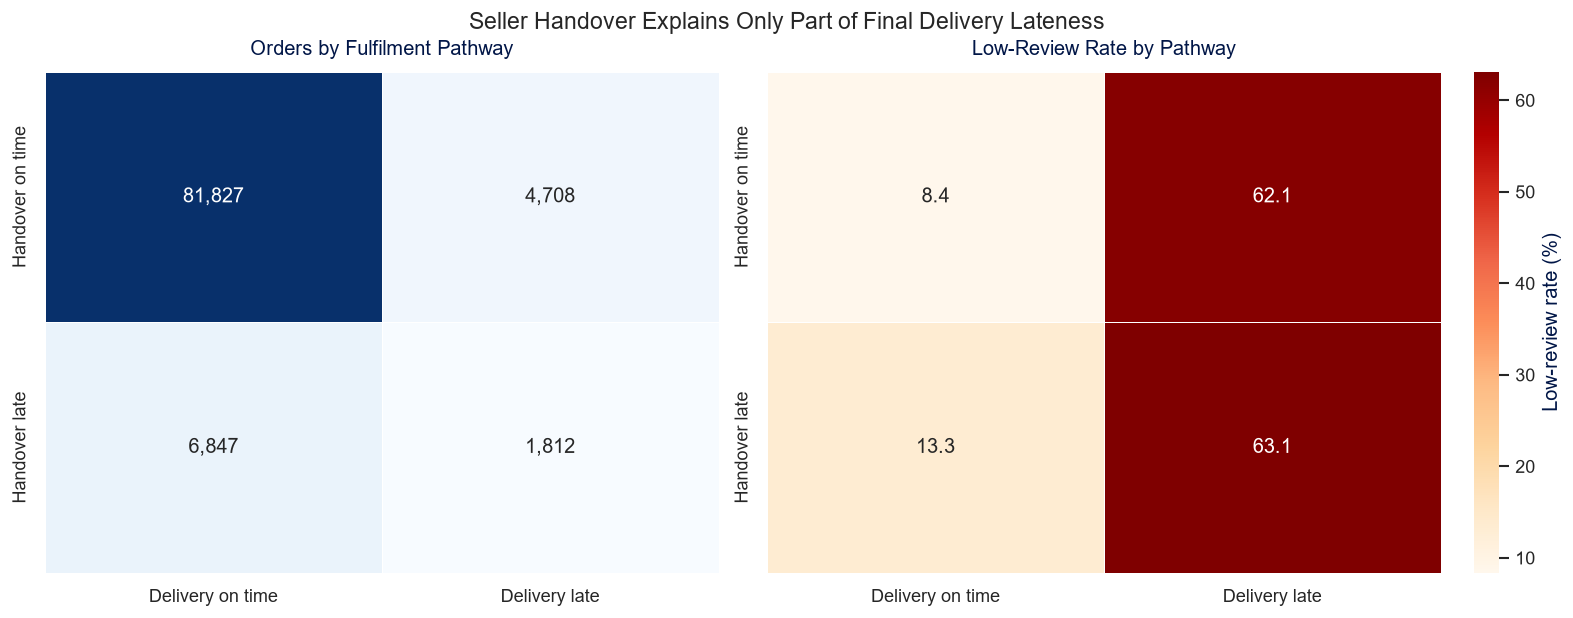

In [52]:
# Visualising volume and low-review rates by fulfilment pathway
fig, axes = plt.subplots(
    1,
    2,
    figsize=(13, 4.8),
    layout="constrained"
)

sns.heatmap(
    stage_count_matrix,
    annot=True,
    fmt=",.0f",
    cmap="Blues",
    cbar=False,
    linewidths=0.5,
    ax=axes[0]
)

axes[0].set_title(
    "Orders by Fulfilment Pathway",
    pad=10
)
axes[0].set_xlabel("")
axes[0].set_ylabel("")

sns.heatmap(
    stage_review_matrix,
    annot=True,
    fmt=".1f",
    cmap="OrRd",
    mask=stage_review_matrix.isna(),
    linewidths=0.5,
    cbar_kws={
        "label": "Low-review rate (%)"
    },
    ax=axes[1]
)

axes[1].set_title(
    "Low-Review Rate by Pathway",
    pad=10
)
axes[1].set_xlabel("")
axes[1].set_ylabel("")

fig.suptitle(
    "Seller Handover Explains Only Part "
    "of Final Delivery Lateness",
    fontsize=14,
    y=1.04
)

plt.show()

In [53]:
# Measuring the share of final late deliveries with a missed seller deadline
final_late_stage_df = stage_df[stage_df["is_late_delivery"]]
late_handover_share = final_late_stage_df["late_seller_handover"].mean()

stage_findings = pd.Series({
    "final_late_orders_with_stage_data": len(final_late_stage_df),
    "late_handover_and_late_delivery": final_late_stage_df["late_seller_handover"].sum(),
    "on_time_handover_but_late_delivery": (~final_late_stage_df["late_seller_handover"]).sum(),
    "late_handover_share_of_final_late_pct": late_handover_share * 100
})
display(stage_findings.round(2).to_frame("value"))

,value
final_late_orders_with_stage_data,6520.00
late_handover_and_late_delivery,1812.00
on_time_handover_but_late_delivery,4708.00
late_handover_share_of_final_late_pct,27.79


Seller alerts can address missed shipping deadlines. They cannot resolve orders
that were handed over on time but arrived late. Those cases require route and
carrier monitoring, while delivery-record discrepancies require stronger
confirmation and proof-of-delivery controls.

## 10. Identify seller priorities

Sellers require at least 30 delivered orders with observable stage data. Ranking
uses excess late-order volume rather than rate alone, balancing operational scale
with performance. Reconciled non-receipt indicators provide supporting evidence.

In [54]:
# Summarising delivery and handover outcomes by seller
seller_summary_df = (
    stage_df
    .groupby("seller_id", as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        late_deliveries=("is_late_delivery", "sum"),
        late_delivery_rate=("is_late_delivery", "mean"),
        missed_handovers=("late_seller_handover", "sum"),
        missed_handover_rate=("late_seller_handover", "mean"),
        reviewed_orders=("review_score", "count"),
        low_reviews=("low_review", "sum"),
        low_review_rate=("low_review", "mean")
    )
)

In [55]:
# Counting reconciled delivery reports across all single-seller orders
seller_issue_summary_df = (
    order_analysis_df[
        (order_analysis_df["seller_count"] == 1)
        & order_analysis_df["seller_id"].notna()
    ]
    .groupby("seller_id", as_index=False)
    .agg(
        all_orders=("order_id", "nunique"),
        non_receipt_reports=("reported_non_receipt", "sum"),
        delivery_record_discrepancies=(
            "delivery_record_discrepancy", "sum"
        ),
        no_recorded_delivery_reports=(
            "no_recorded_delivery_report", "sum"
        )
    )
)
seller_summary_df = seller_summary_df.merge(
    seller_issue_summary_df,
    on="seller_id", how="left", validate="one_to_one"
)
seller_issue_columns = [
    "all_orders", "non_receipt_reports",
    "delivery_record_discrepancies",
    "no_recorded_delivery_reports"
]
seller_summary_df[seller_issue_columns] = (
    seller_summary_df[seller_issue_columns].fillna(0)
)

In [56]:
# Ranking sufficiently observed sellers by excess late orders
minimum_seller_orders = 30
comparison_late_rate = stage_df["is_late_delivery"].mean()
seller_priority_df = seller_summary_df[
    seller_summary_df["delivered_orders"] >= minimum_seller_orders
].copy()
seller_priority_df["expected_late_orders"] = (
    seller_priority_df["delivered_orders"] * comparison_late_rate
)
seller_priority_df["excess_late_orders"] = np.maximum(
    0,
    seller_priority_df["late_deliveries"]
    - seller_priority_df["expected_late_orders"]
)
seller_priority_df["non_receipt_report_rate_pct"] = (
    seller_priority_df["non_receipt_reports"]
    / seller_priority_df["all_orders"] * 100
)

In [57]:
# Displaying the highest-impact seller priorities
seller_priority_df["late_delivery_rate_pct"] = (
    seller_priority_df["late_delivery_rate"] * 100
)
seller_priority_df["missed_handover_rate_pct"] = (
    seller_priority_df["missed_handover_rate"] * 100
)
seller_priority_df["low_review_rate_pct"] = (
    seller_priority_df["low_review_rate"] * 100
)
seller_priority_df = seller_priority_df.sort_values(
    ["excess_late_orders", "non_receipt_reports", "delivered_orders"],
    ascending=[False, False, False]
)

seller_display_columns = [
    "seller_id", "delivered_orders", "late_deliveries",
    "late_delivery_rate_pct", "missed_handover_rate_pct",
    "low_review_rate_pct", "non_receipt_reports",
    "delivery_record_discrepancies", "excess_late_orders"
]
display(seller_priority_df[seller_display_columns].head(15).round(2))

,seller_id,delivered_orders,late_deliveries,late_delivery_rate_pct,missed_handover_rate_pct,low_review_rate_pct,non_receipt_reports,delivery_record_discrepancies,excess_late_orders
851,4a3ca9315b744ce9f8e9374361493884,1673,168,10.04,9.03,16.98,29,10,53.41
78,06a2c3af7b3aee5d69171b0e14f0ee87,388,74,19.07,31.19,15.89,6,0,47.43
827,4869f7a5dfa277a7dca6462dcf3b52b2,1111,118,10.62,5.58,12.24,9,2,41.91
356,1f50f920176fa81dab994f9023523100,1364,124,9.09,10.92,12.88,11,1,30.58
1520,8160255418d5aaa7dbdc9f4c64ebda44,355,51,14.37,25.35,14.53,2,0,26.69
1473,7d13fca15225358621be4086e1eb0964,548,64,11.68,15.15,16.33,6,2,26.47
1594,88460e8ebdecbfecb5f9601833981930,227,42,18.50,51.10,28.32,3,1,26.45
1469,7c67e1448b00f6e969d365cea6b010ab,963,89,9.24,29.91,25.08,10,3,23.04
2704,ea8482cd71df3c1969d7b9473ff13abc,1116,96,8.60,7.80,13.87,8,5,19.56
2636,e5a3438891c0bfdb9394643f95273d8e,213,34,15.96,17.84,16.98,5,0,19.41


## 11. Identify state-route priorities

Carrier identity is unavailable, so seller-state to customer-state routes are
the most detailed repeatable logistics unit. Route rankings indicate where
carrier-level data collection and operational investigation are most valuable.

In [58]:
# Creating delivered-order route metrics
route_summary_df = (
    stage_df
    .dropna(subset=["seller_state", "customer_state"])
    .groupby(["seller_state", "customer_state"], as_index=False)
    .agg(
        delivered_orders=("order_id", "nunique"),
        late_deliveries=("is_late_delivery", "sum"),
        late_delivery_rate=("is_late_delivery", "mean"),
        reviewed_orders=("review_score", "count"),
        low_review_rate=("low_review", "mean"),
        median_delivery_days=("actual_delivery_days", "median")
    )
)
route_summary_df["route"] = (
    route_summary_df["seller_state"]
    + " → " + route_summary_df["customer_state"]
)

In [59]:
# Counting reconciled reports across single-seller state routes
route_issue_summary_df = (
    order_analysis_df[
        (order_analysis_df["seller_count"] == 1)
        & order_analysis_df["seller_state"].notna()
        & order_analysis_df["customer_state"].notna()
    ]
    .groupby(["seller_state", "customer_state"], as_index=False)
    .agg(
        all_orders=("order_id", "nunique"),
        non_receipt_reports=("reported_non_receipt", "sum"),
        delivery_record_discrepancies=(
            "delivery_record_discrepancy", "sum"
        )
    )
)
route_summary_df = route_summary_df.merge(
    route_issue_summary_df,
    on=["seller_state", "customer_state"],
    how="left", validate="one_to_one"
)
route_issue_columns = [
    "all_orders", "non_receipt_reports",
    "delivery_record_discrepancies"
]
route_summary_df[route_issue_columns] = (
    route_summary_df[route_issue_columns].fillna(0)
)

In [60]:
# Ranking high-volume routes by excess late deliveries
minimum_route_orders = 100
route_priority_df = route_summary_df[
    route_summary_df["delivered_orders"] >= minimum_route_orders
].copy()
route_priority_df["expected_late_orders"] = (
    route_priority_df["delivered_orders"] * comparison_late_rate
)
route_priority_df["excess_late_orders"] = np.maximum(
    0,
    route_priority_df["late_deliveries"]
    - route_priority_df["expected_late_orders"]
)
route_priority_df["late_delivery_rate_pct"] = (
    route_priority_df["late_delivery_rate"] * 100
)
route_priority_df["low_review_rate_pct"] = (
    route_priority_df["low_review_rate"] * 100
)
route_priority_df["non_receipt_report_rate_pct"] = (
    route_priority_df["non_receipt_reports"]
    / route_priority_df["all_orders"] * 100
)

In [61]:
# Displaying the highest-impact route priorities
route_priority_df = route_priority_df.sort_values(
    ["excess_late_orders", "non_receipt_reports", "delivered_orders"],
    ascending=[False, False, False]
)
route_display_columns = [
    "route", "delivered_orders", "late_deliveries",
    "late_delivery_rate_pct", "median_delivery_days",
    "low_review_rate_pct", "non_receipt_reports",
    "delivery_record_discrepancies", "excess_late_orders"
]
display(route_priority_df[route_display_columns].head(15).round(2))

,route,delivered_orders,late_deliveries,late_delivery_rate_pct,median_delivery_days,low_review_rate_pct,non_receipt_reports,delivery_record_discrepancies,excess_late_orders
399,SP → RJ,8048,1147,14.25,13.0,19.75,134,29,595.78
385,SP → BA,2278,297,13.04,18.0,17.76,33,8,140.98
388,SP → ES,1444,180,12.47,14.0,14.34,21,7,81.10
386,SP → CE,961,133,13.84,18.0,16.63,21,5,67.18
404,SP → SC,2306,222,9.63,14.0,14.61,29,9,64.06
390,SP → MA,486,93,19.14,20.0,21.99,5,1,59.71
268,PR → RJ,951,117,12.30,14.0,19.51,12,5,51.86
382,SP → AL,254,61,24.02,23.0,24.21,4,1,43.60
394,SP → PA,675,81,12.00,21.0,17.57,11,2,34.77
396,SP → PE,1126,111,9.86,16.0,15.17,17,5,33.88


In [62]:
# Preparing a readable state-route heatmap
top_seller_states = (
    stage_df["seller_state"].value_counts().head(8).index
)
top_customer_states = (
    stage_df["customer_state"].value_counts().head(12).index
)

heatmap_source_df = route_summary_df[
    route_summary_df["seller_state"].isin(top_seller_states)
    & route_summary_df["customer_state"].isin(top_customer_states)
    & (route_summary_df["delivered_orders"] >= minimum_route_orders)
]

route_heatmap_df = heatmap_source_df.pivot(
    index="seller_state",
    columns="customer_state",
    values="late_delivery_rate"
) * 100

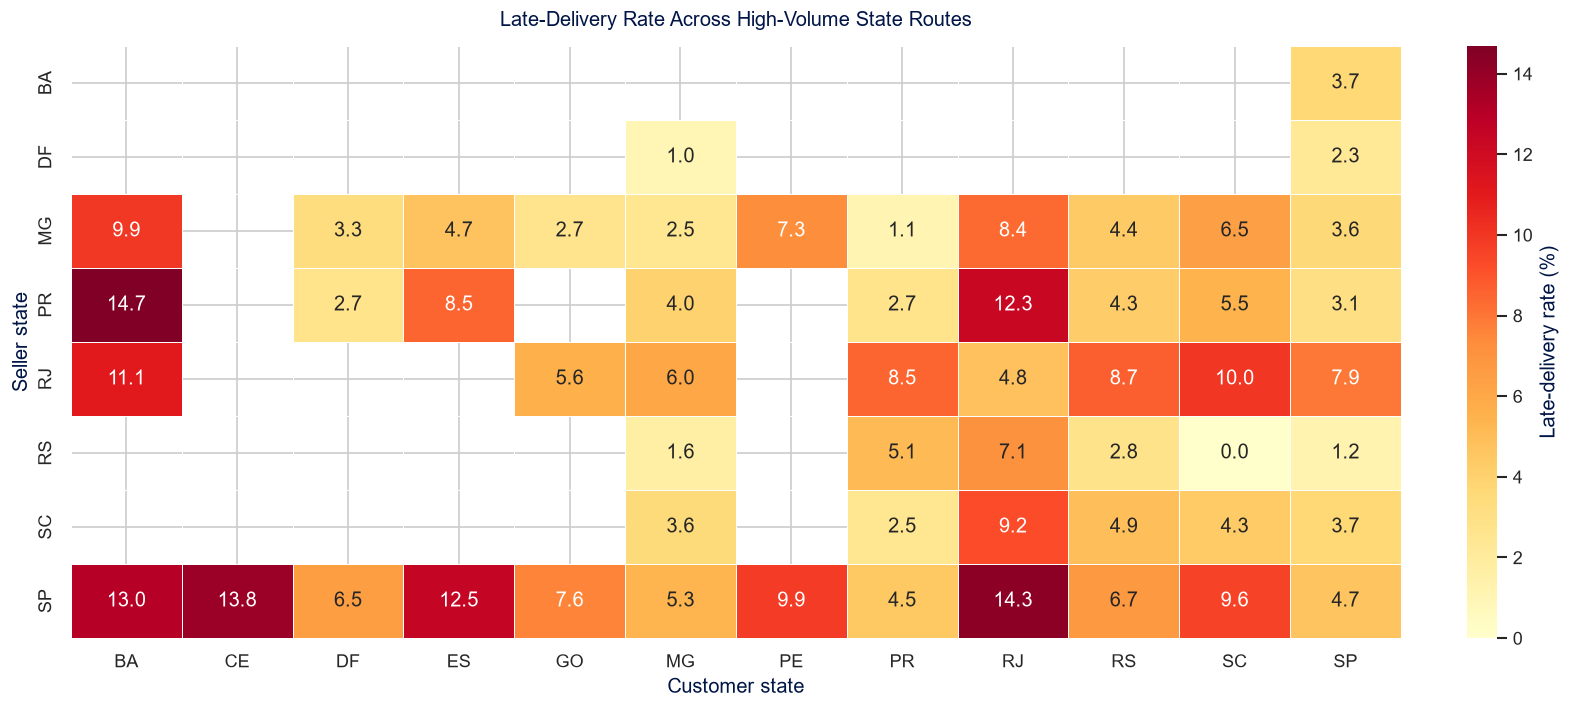

In [63]:
# Visualising late-delivery rates across major state routes
fig, ax = plt.subplots(figsize=(13, 5.8), layout="constrained")
sns.heatmap(
    route_heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    mask=route_heatmap_df.isna(),
    cbar_kws={"label": "Late-delivery rate (%)"},
    ax=ax
)
ax.set_title("Late-Delivery Rate Across High-Volume State Routes", pad=12)
ax.set_xlabel("Customer state")
ax.set_ylabel("Seller state")
plt.show()

## 12. Protect the value of cross-state marketplace access

Cross-state purchasing is not automatically a failure. It may provide products
that were not historically sold by sellers in the customer’s state or offer a
lower observed item price. The comparison uses exact `product_id`, excludes
freight and treats transaction history as a proxy—not proof of inventory shown
at checkout.

In [64]:
# Building an item-level view of buyer and seller geography
item_market_df = items_df.merge(
    order_analysis_df[[
        "order_id",
        "order_purchase_timestamp",
        "order_status",
        "customer_state"
    ]],
    on="order_id",
    how="left",
    validate="many_to_one"
)

if "seller_state" not in item_market_df.columns:
    item_market_df = item_market_df.merge(
        sellers_df[["seller_id", "seller_state"]],
        on="seller_id",
        how="left",
        validate="many_to_one"
    )

In [65]:
# Keeping valid delivered items with usable price and state fields
item_market_df = item_market_df[
    (item_market_df["order_status"] == "delivered")
    & item_market_df["customer_state"].notna()
    & item_market_df["seller_state"].notna()
    & item_market_df["price"].notna()
    & (item_market_df["price"] > 0)
].copy()

item_market_df["purchase_month"] = (
    item_market_df["order_purchase_timestamp"]
    .dt.to_period("M")
    .dt.to_timestamp()
)

cross_state_items_df = item_market_df[
    item_market_df["customer_state"]
    != item_market_df["seller_state"]
].copy()

In [66]:
# Summarising exact-product prices observed from sellers in each state
local_history_price_df = (
    item_market_df
    .groupby(["product_id", "seller_state"], as_index=False)
    .agg(
        local_history_median_price=("price", "median"),
        local_history_min_price=("price", "min"),
        local_history_transactions=("price", "size")
    )
    .rename(columns={"seller_state": "customer_state"})
)

In [67]:
# Creating a same-month local price reference
local_month_price_df = (
    item_market_df
    .groupby([
        "product_id",
        "seller_state",
        "purchase_month"
    ], as_index=False)
    .agg(
        local_month_median_price=("price", "median"),
        local_month_min_price=("price", "min"),
        local_month_transactions=("price", "size")
    )
    .rename(columns={"seller_state": "customer_state"})
)

In [68]:
# Matching each cross-state item to historical local observations
cross_state_price_df = cross_state_items_df.merge(
    local_history_price_df,
    on=["product_id", "customer_state"],
    how="left",
    validate="many_to_one"
)

cross_state_price_df = cross_state_price_df.merge(
    local_month_price_df,
    on=["product_id", "customer_state", "purchase_month"],
    how="left",
    validate="many_to_one"
)

In [69]:
# Measuring the observed price difference without freight
cross_state_price_df["price_gap_pct"] = (
    (
        cross_state_price_df["price"]
        - cross_state_price_df["local_month_median_price"]
    )
    / cross_state_price_df["local_month_median_price"]
    * 100
)

has_local_history = cross_state_price_df[
    "local_history_transactions"
].notna()
has_local_month = cross_state_price_df[
    "local_month_transactions"
].notna()

In [70]:
# Classifying the historical explanation supported by each comparison
price_context_conditions = [
    ~has_local_history,
    has_local_history & ~has_local_month,
    cross_state_price_df["price_gap_pct"] <= -5,
    cross_state_price_df["price_gap_pct"] < 5
]

price_context_labels = [
    "No historical local sale observed",
    "No same-month local sale observed",
    "Cross-state price at least 5% lower",
    "Similar observed price"
]

cross_state_price_df["purchase_context"] = np.select(
    price_context_conditions,
    price_context_labels,
    default="Local median price at least 5% lower"
)

In [71]:
# Summarising the cross-state purchase context
context_order = [
    "No historical local sale observed",
    "No same-month local sale observed",
    "Cross-state price at least 5% lower",
    "Similar observed price",
    "Local median price at least 5% lower"
]

price_context_summary_df = (
    cross_state_price_df
    .groupby("purchase_context", as_index=False)
    .agg(
        order_items=("order_item_id", "size"),
        orders=("order_id", "nunique"),
        item_value=("price", "sum")
    )
    .set_index("purchase_context")
    .reindex(context_order, fill_value=0)
    .reset_index()
)

price_context_summary_df["item_share_pct"] = (
    price_context_summary_df["order_items"]
    / price_context_summary_df["order_items"].sum()
    * 100
)
display(price_context_summary_df.round(2))

,purchase_context,order_items,orders,item_value,item_share_pct
0,No historical local sale observed,69076,60821,8930613.19,98.22
1,No same-month local sale observed,1046,922,133423.92,1.49
2,Cross-state price at least 5% lower,47,45,5545.61,0.07
3,Similar observed price,134,120,14532.68,0.19
4,Local median price at least 5% lower,28,28,3078.04,0.04


In [72]:
# Reporting the coverage and price evidence
same_month_comparisons_df = cross_state_price_df[
    has_local_month
].copy()

cross_state_context_kpis = pd.Series({
    "cross_state_items": len(cross_state_price_df),
    "cross_state_orders": cross_state_price_df["order_id"].nunique(),
    "no_historical_local_sale_pct": (~has_local_history).mean() * 100,
    "same_month_price_comparison_pct": has_local_month.mean() * 100,
    "cross_state_at_least_5_pct_cheaper": (
        same_month_comparisons_df["price_gap_pct"] <= -5
    ).mean() * 100,
    "median_same_month_price_gap_pct": (
        same_month_comparisons_df["price_gap_pct"].median()
    )
})
display(cross_state_context_kpis.round(2).to_frame("value"))

,value
cross_state_items,70331.00
cross_state_orders,61898.00
no_historical_local_sale_pct,98.22
same_month_price_comparison_pct,0.30
cross_state_at_least_5_pct_cheaper,22.49
median_same_month_price_gap_pct,0.00


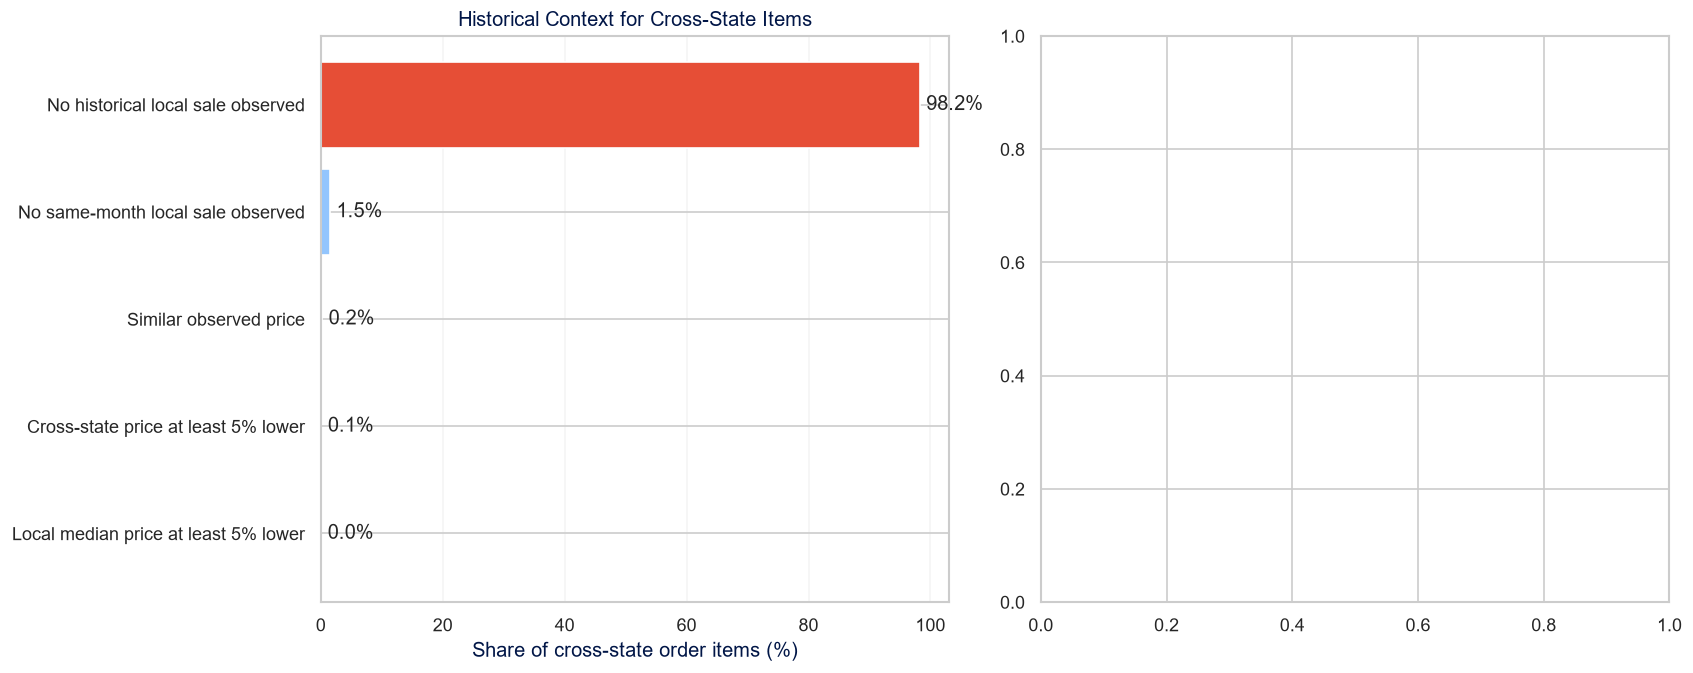

In [73]:
# Visualising historical supply and price explanations
plot_context_df = price_context_summary_df.sort_values(
    "item_share_pct"
)

fig, axes = plt.subplots(
    1,
    2,
    figsize=(14, 5.5),
    layout="constrained"
)

bars = axes[0].barh(
    plot_context_df["purchase_context"],
    plot_context_df["item_share_pct"],
    color=[LIGHT_BLUE, "#D1D5DB", BLUE, "#93C5FD", ORANGE]
)
axes[0].bar_label(bars, fmt="%.1f%%", padding=4)
axes[0].set_title("Historical Context for Cross-State Items")
axes[0].set_xlabel("Share of cross-state order items (%)")
axes[0].set_ylabel("")
axes[0].grid(axis="x", alpha=0.2)

In [74]:
# Continuing the exact-product price visual
price_gap_plot = same_month_comparisons_df[
    "price_gap_pct"
].dropna()

if len(price_gap_plot):
    lower_limit = price_gap_plot.quantile(0.01)
    upper_limit = price_gap_plot.quantile(0.99)
    displayed_price_gap = price_gap_plot.clip(
        lower=lower_limit,
        upper=upper_limit
    )

    axes[1].hist(displayed_price_gap, bins=35, color=BLUE, alpha=0.85)
    axes[1].axvline(0, color=NAVY, linewidth=1.5, label="Same price")
    axes[1].axvline(-5, color=ORANGE, linestyle="--", label="5% cheaper")
    axes[1].set_title("Exact-Product Price Gap Where Local Sales Exist")
    axes[1].set_xlabel("Cross-state price minus local median (%)")
    axes[1].set_ylabel("Order items")
    axes[1].legend(frameon=False)
    axes[1].grid(axis="y", alpha=0.2)

fig.suptitle(
    "Observed Assortment and Price Value of Cross-State Purchasing",
    fontsize=15
)
plt.show()

### Cross-state interpretation

The comparison supplies context rather than a causal explanation of customer
choice. Routes should be prioritised using excess failure volume, not blocked
merely because seller and customer states differ. Any delivery intervention must
preserve the assortment access that cross-state commerce appears to provide.

## 13. Translate the diagnosis into operational controls

The evidence supports three complementary controls. Each responds to a different
observable failure rather than treating every delivery problem as a seller delay.

In [75]:
# Defining the operational intervention framework
intervention_framework_df = pd.DataFrame([
    {
        "control": "Seller deadline alert",
        "trigger": "No handover 24 hours before the earliest shipping deadline",
        "action": "Automated reminder; escalate unresolved orders six hours before deadline",
        "owner": "Seller operations",
        "primary_kpi": "Missed-handover rate"
    },
    {
        "control": "In-transit route monitoring",
        "trigger": "Elapsed transit time exceeds the route-specific expected milestone",
        "action": "Logistics escalation and proactive customer update",
        "owner": "Logistics operations",
        "primary_kpi": "Late-delivery rate"
    },
    {
        "control": "Delivery confirmation integrity",
        "trigger": "Order marked delivered on a high-discrepancy seller or route",
        "action": "Stronger proof of delivery and rapid non-receipt resolution",
        "owner": "Logistics and customer support",
        "primary_kpi": "Post-delivery non-receipt report rate"
    }
])
display(intervention_framework_df)

,control,trigger,action,owner,primary_kpi
0,Seller deadline alert,No handover 24 hours before the earliest shipp...,Automated reminder; escalate unresolved orders...,Seller operations,Missed-handover rate
1,In-transit route monitoring,Elapsed transit time exceeds the route-specifi...,Logistics escalation and proactive customer up...,Logistics operations,Late-delivery rate
2,Delivery confirmation integrity,Order marked delivered on a high-discrepancy s...,Stronger proof of delivery and rapid non-recei...,Logistics and customer support,Post-delivery non-receipt report rate


## 14. Size transparent what-if scenarios

The scenarios answer a planning question: if a control prevented 10%, 20% or
30% of the historically targetable late cases, how would the overall delivered-
order late rate change? These are arithmetic scenarios, not forecasts.

In [76]:
# Defining historically targetable late-order groups
seller_targetable_orders = int(
    (
        stage_df["late_seller_handover"]
        & stage_df["is_late_delivery"]
    ).sum()
)
transit_targetable_orders = int(
    (
        ~stage_df["late_seller_handover"]
        & stage_df["is_late_delivery"]
    ).sum()
)
baseline_late_orders = int(delivery_df["is_late_delivery"].sum())
baseline_late_rate = baseline_late_orders / len(delivery_df)
low_review_rate_gap = late_low_rate - on_time_low_rate
scenario_reductions = [0.10, 0.20, 0.30]

In [77]:
# Calculating stage-specific late-delivery scenarios
scenario_rows = []

for intervention, targetable_orders in [
    ("Seller handover control", seller_targetable_orders),
    ("In-transit route control", transit_targetable_orders)
]:
    for reduction in scenario_reductions:
        fewer_late_orders = targetable_orders * reduction
        projected_late_orders = baseline_late_orders - fewer_late_orders
        projected_late_rate = projected_late_orders / len(delivery_df)
        scenario_rows.append({
            "intervention": intervention,
            "relative_reduction_in_target_group_pct": reduction * 100,
            "fewer_late_orders": fewer_late_orders,
            "projected_overall_late_rate_pct": projected_late_rate * 100,
            "overall_late_rate_reduction_pp": (
                baseline_late_rate - projected_late_rate
            ) * 100,
            "illustrative_fewer_excess_low_reviews": (
                fewer_late_orders * low_review_rate_gap
            )
        })

intervention_scenarios_df = pd.DataFrame(scenario_rows)
display(intervention_scenarios_df.round(2))

,intervention,relative_reduction_in_target_group_pct,fewer_late_orders,projected_overall_late_rate_pct,overall_late_rate_reduction_pp,illustrative_fewer_excess_low_reviews
0,Seller handover control,10.0,181.2,6.59,0.19,96.31
1,Seller handover control,20.0,362.4,6.40,0.38,192.62
2,Seller handover control,30.0,543.6,6.21,0.56,288.94
3,In-transit route control,10.0,470.8,6.29,0.49,250.24
4,In-transit route control,20.0,941.6,5.80,0.98,500.48
5,In-transit route control,30.0,1412.4,5.31,1.46,750.72


In [78]:
# Sizing delivery-confirmation integrity scenarios separately
discrepancy_reports = int(
    order_analysis_df["delivery_record_discrepancy"].sum()
)
discrepancy_scenario_df = pd.DataFrame({
    "relative_reduction_pct": [10, 20, 30]
})
discrepancy_scenario_df["fewer_discrepancy_reports"] = (
    discrepancy_reports
    * discrepancy_scenario_df["relative_reduction_pct"] / 100
)
discrepancy_scenario_df["remaining_discrepancy_reports"] = (
    discrepancy_reports
    - discrepancy_scenario_df["fewer_discrepancy_reports"]
)
display(discrepancy_scenario_df.round(1))

,relative_reduction_pct,fewer_discrepancy_reports,remaining_discrepancy_reports
0,10,39.1,351.9
1,20,78.2,312.8
2,30,117.3,273.7


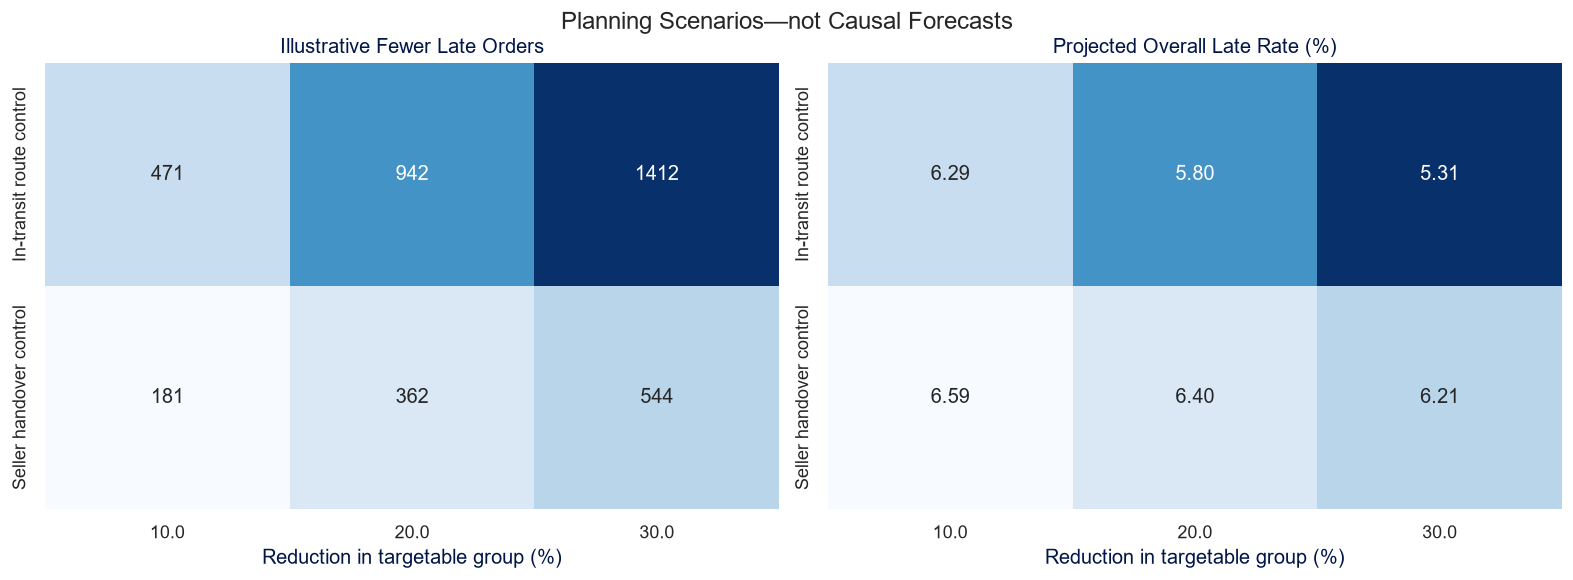

In [79]:
# Visualising the direct impact on the overall late-delivery rate
scenario_rate_matrix = intervention_scenarios_df.pivot(
    index="intervention",
    columns="relative_reduction_in_target_group_pct",
    values="projected_overall_late_rate_pct"
)
scenario_order_matrix = intervention_scenarios_df.pivot(
    index="intervention",
    columns="relative_reduction_in_target_group_pct",
    values="fewer_late_orders"
)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), layout="constrained")
sns.heatmap(
    scenario_order_matrix, annot=True, fmt=".0f",
    cmap="Blues", cbar=False, ax=axes[0]
)
sns.heatmap(
    scenario_rate_matrix, annot=True, fmt=".2f",
    cmap="Blues_r", cbar=False, ax=axes[1]
)
axes[0].set_title("Illustrative Fewer Late Orders")
axes[1].set_title("Projected Overall Late Rate (%)")
for axis in axes:
    axis.set_xlabel("Reduction in targetable group (%)")
    axis.set_ylabel("")
fig.suptitle("Planning Scenarios—not Causal Forecasts", y=1.04)
plt.show()

## 15. Recommended controlled pilots

### Pilot A — Seller-deadline alerts

- **Population:** sufficiently observed sellers with elevated missed-handover
  rates and excess late-order volume.
- **Assignment:** randomise sellers to avoid treatment spillover across their
  orders.
- **Treatment:** reminder 24 hours before the earliest shipping deadline and
  escalation six hours before the deadline when handover remains unresolved.
- **Primary KPI:** missed-handover rate.
- **Secondary KPIs:** final late-delivery rate, days late and low-review rate.

### Pilot B — In-transit route monitoring

- **Population:** high-volume routes with excess late deliveries after on-time
  seller handover.
- **Prerequisite:** capture carrier identity and tracking milestones.
- **Treatment:** route-specific delay alerts, logistics escalation and proactive
  customer updates.
- **Primary KPI:** final late-delivery rate.
- **Secondary KPIs:** days late, contact rate and low-review rate.

### Pilot C — Delivery confirmation integrity

- **Population:** high-volume sellers or routes with elevated reports submitted
  after the order was marked delivered.
- **Treatment:** stronger proof of delivery, delivery confirmation messaging and
  a rapid non-receipt resolution path.
- **Primary KPI:** post-delivery non-receipt report rate.
- **Guardrails:** support contacts, refunds and customer-resolution time.

Before launch, calculate statistical power using each selected pilot population’s
baseline rate. Report intention-to-treat effects and confidence intervals rather
than comparing treated orders with self-selected historical controls.

## 16. Conclusions and management recommendation

1. Most Olist orders were delivered successfully, so a platform-wide overhaul
   is not supported.
2. The review-text handoff shows that non-receipt and slow delivery are prominent
   within severe named complaints, while structured data tests their operational
   consequences.
3. Objective lateness should be evaluated through its low-score risk difference
   and concentration, not its overall frequency alone.
4. Seller handover explains only one portion of final lateness; seller reminders
   cannot fix failures that develop after carrier handover.
5. Seller and route priority tables identify high-volume sources of excess late
   orders and prevent resources being spread across every transaction.
6. Cross-state commerce appears to provide valuable assortment access, so
   interventions should improve risky routes rather than discourage cross-state
   purchasing.
7. Delivery-record discrepancies represent a separate integrity and recovery
   problem requiring proof-of-delivery controls.
8. The scenarios define measurable planning ranges, while the proposed pilots
   are required to estimate causal impact.

## 17. Limitations

- Carrier identity and parcel-level tracking milestones are unavailable.
- One order-level carrier timestamp cannot attribute multi-seller delays.
- Review scores may reflect product and service factors beyond delivery.
- Topic labels are model-assisted and the unassigned residual remains material.
- A transaction history cannot show listings, stock or prices visible at checkout.
- Exact-product price comparisons describe observed alternatives, not customer
  motivation.
- Historical what-if scenarios are not causal impact estimates.
- Revenue, margin, support and refund costs are unavailable, preventing complete
  financial ROI measurement.

## 18. Export decision-ready outputs

These tables support a Power BI operational page, seller-success workflow or
future alerting prototype.

In [80]:
# Creating the delivery-reliability output folder
output_dir = Path("outputs/delivery_reliability_analysis")
output_dir.mkdir(parents=True, exist_ok=True)

delivery_kpis.to_csv(
    output_dir / "delivery_baseline_kpis.csv", header=["value"]
)
review_handoff_kpis.to_csv(
    output_dir / "review_handoff_kpis.csv", header=["orders"]
)
association_results.to_csv(
    output_dir / "delivery_rating_association.csv", header=["value"]
)
stage_summary_df.to_csv(
    output_dir / "fulfilment_stage_summary.csv", index=False
)

In [81]:
# Saving operational priority tables
seller_priority_df.to_csv(
    output_dir / "seller_delivery_priority.csv", index=False
)
route_priority_df.to_csv(
    output_dir / "route_delivery_priority.csv", index=False
)
price_context_summary_df.to_csv(
    output_dir / "cross_state_price_context_summary.csv", index=False
)
intervention_scenarios_df.to_csv(
    output_dir / "delivery_intervention_scenarios.csv", index=False
)
discrepancy_scenario_df.to_csv(
    output_dir / "delivery_confirmation_scenarios.csv", index=False
)
intervention_framework_df.to_csv(
    output_dir / "delivery_intervention_framework.csv", index=False
)

In [83]:
# Saving the order-level reconciled delivery evidence
order_delivery_export_df = order_analysis_df.copy()
delivery_metric_lookup = delivery_df.set_index("order_id")

for column in [
    "is_late_delivery", "delivery_delay_days", "low_review"
]:
    order_delivery_export_df[column] = (
        order_delivery_export_df["order_id"]
        .map(delivery_metric_lookup[column])
    )

delivery_export_columns = [
    "order_id", "order_status", "customer_state", "seller_state",
    "seller_id", "primary_category", "carrier_handover_deadline",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date", "is_late_delivery",
    "delivery_delay_days", "review_score", "low_review",
    "reported_non_receipt", "recorded_outcome"
]
order_delivery_export_df[delivery_export_columns].to_parquet(
    output_dir / "order_delivery_analysis_ready.parquet", index=False
)

print(f"Outputs saved under: {output_dir.resolve()}")

Outputs saved under: C:\Users\user\Desktop\olist_analytics\analysis\outputs\delivery_reliability_analysis
